# Dimension Reduction, PCA & PCR — Homework Assignment

## Course: Business Analytics with R

**Total Points: 100**

### Instructions
1. Complete all tasks by writing R code in the provided cells
2. Run each cell to verify your code works correctly
3. Comment your code to explain your reasoning
4. Show your output — do not suppress results
5. Answer all interpretation questions in comments or markdown

### Skills Tested
- Data loading, inspection, and missing value checks
- Normalization / standardization (`scale()`)
- Correlation analysis and visualization
- Principal Component Analysis (PCA) — scree plots, loadings, biplots
- Component interpretation and naming
- Principal Component Regression (PCR) — fitting, cross-validation, prediction
- RMSE evaluation

### Datasets
All data files are in the `data/module_3/` folder of this repository:
- **PCA:** `PCA_Protein_data.csv` (European protein consumption by country)
- **PCR:** `PCR_TRAIN DATA.csv` and `PCR_TEST DATA.csv` (spectrometric readings)

**Data Path Hint:** Use `read.csv("../data/module_3/FILENAME.csv", header = TRUE)` to load files from this Homework folder.

---

## Setup: Load Required Libraries

Run this cell first to load all necessary packages.

In [25]:
# Load required libraries
library(corrr)
library(ggcorrplot)
library(FactoMineR)
library(factoextra)
library(pls)

---

## Part 1: Data Exploration & Preparation (20 points)

Before running PCA, we need to understand and prepare the data.

### Task 1.1: Load and Inspect the Protein Data (5 points)

Load `PCA_Protein_data.csv` from the `data/module_3/` folder. Store it in a variable called `protein`. Display the first 6 rows.

In [26]:
protein <- read.csv("../data/module_3/PCA_Protein_data.csv")
head(protein)

,Country,RedMeat,WhiteMeat,Eggs,Milk,Fish,Cereals,Starch,Nuts,Fr.Veg
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Albania,10.1,1.4,0.5,8.9,0.2,42.3,0.6,5.5,1.7
2,Austria,8.9,14.0,4.3,19.9,2.1,28.0,3.6,1.3,4.3
3,Belgium,13.5,9.3,4.1,17.5,4.5,26.6,5.7,2.1,4.0
4,Bulgaria,7.8,6.0,1.6,8.3,1.2,56.7,1.1,3.7,4.2
5,Czechoslovakia,9.7,11.4,2.8,12.5,2.0,34.3,5.0,1.1,4.0
6,Denmark,10.6,10.8,3.7,25.0,9.9,21.9,4.8,0.7,2.4


### Task 1.2: Check for Missing Values (5 points)

Check whether the dataset has any missing values. Display the total number of NAs across the entire dataset.

In a comment, explain: **Why is it important to check for missing values before running PCA?**

In [27]:
sum(is.na(protein))

[1] 0

It is important to check for missing values before running PCA because PCA is a mathematical procedure variance matrixes that require complete data numerical sets. Missing Values will cause computation errors or produce incorrect results. 

### Task 1.3: Normalize the Data (5 points)

Use `scale()` to standardize only the **numeric columns** (columns 2 through 10 — exclude the Country name column). Store the result in `protein_scaled`.

In a comment, explain: **Why do we need to normalize before PCA? What would happen if one variable was measured in grams and another in kilograms?**

In [28]:
protein_scaled <- scale(protein[, 2:10])

We need to normalize first because PCA identifies maximum direction in the data. If variables are on different scales, PCA will be thrown off by whichever variable has the largest numeric variance. 
For example if one variable is measured in kilograms and the other grams, they represent the same quantity but the scale is very different. PCA would assign nearly all variance to the kilogram variable, making the results completely invalid and misleading. 

### Task 1.4: Correlation Matrix (5 points)

1. Compute the correlation matrix for the scaled data
2. Visualize it using `ggcorrplot()`

In a comment, identify: **Which two food categories have the strongest positive correlation? Which two have the strongest negative correlation?**

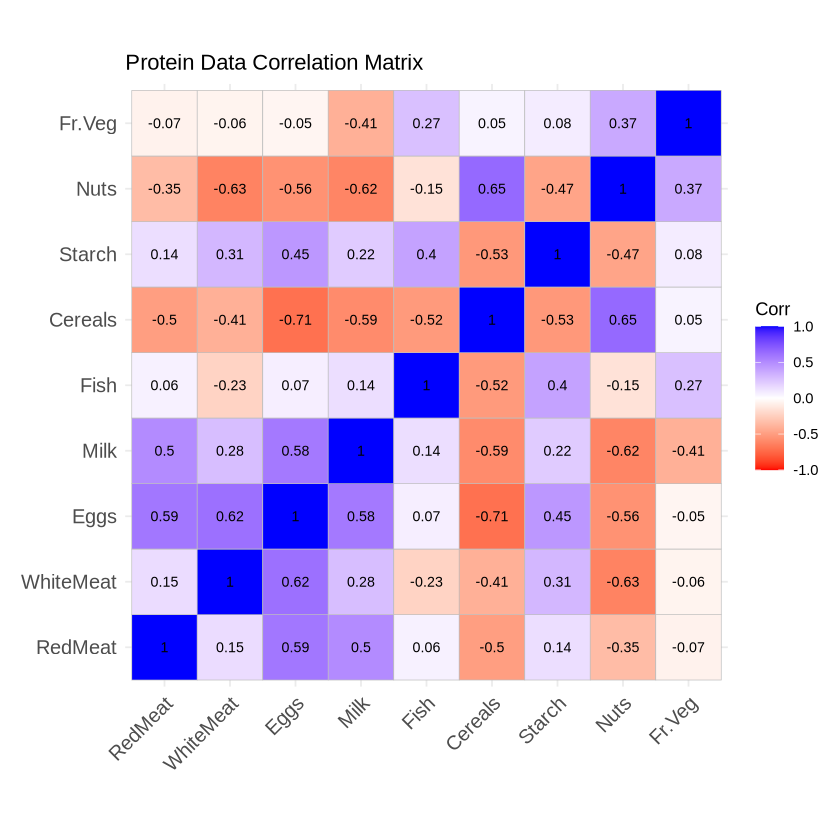

In [29]:
cor_matrix <- cor(protein_scaled)
ggcorrplot(cor_matrix,
           lab = TRUE,
           lab_size = 3,
           colors = c("red", "white", "blue"),
           title = "Protein Data Correlation Matrix")

Eggs and WhiteMeat have the highest positive correlation r = .62 
Eggs and Cereal have the strongest negative correlation r = -.71 

---

## Part 2: Principal Component Analysis (40 points)

Now we'll run PCA and interpret the results.

### Task 2.1: Run PCA (5 points)

Perform PCA on the scaled protein data using the `PCA()` function from FactoMineR. Store the result in `protein_pca`. Use `graph = FALSE` to suppress automatic plots for now.

In [30]:
protein_pca <- PCA(protein_scaled, graph = FALSE)

### Task 2.2: Scree Plot (5 points)

Create a scree plot using `fviz_screeplot()` to visualize the variance explained by each component.

In a comment, answer: **How many components would you retain, and why? Reference the elbow method and/or the 70–90% cumulative variance rule.**

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
“Ignoring empty aesthetic: `width`.”


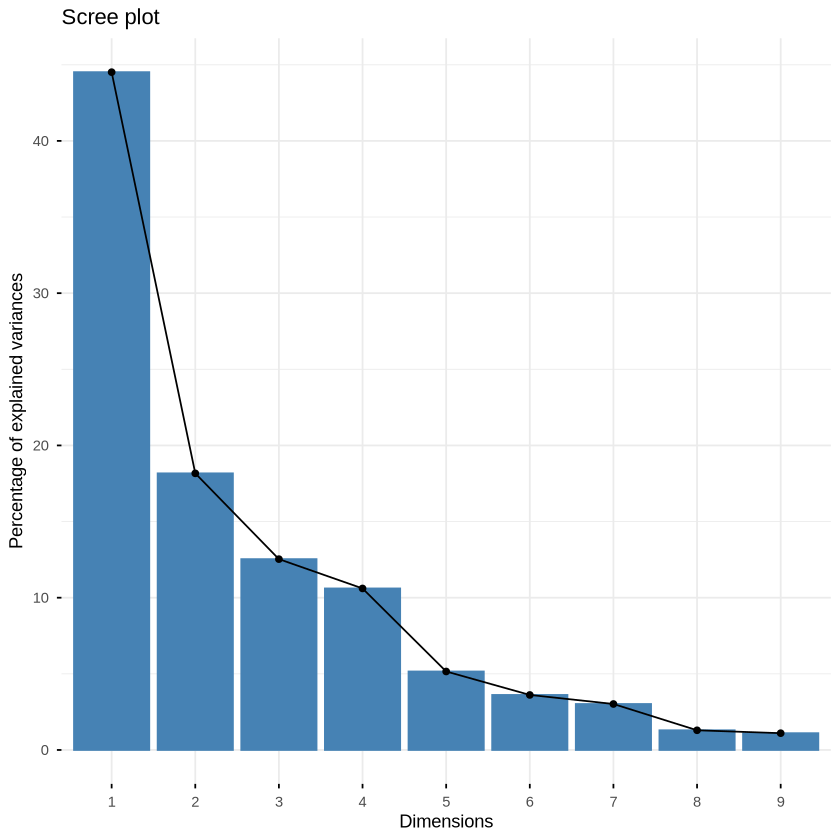

In [31]:
fviz_screeplot(protein_pca)


I would retain 2 principal components because after the 2nd component, there is a clear elbow, where the explained variance drops off. The first two components capture the majority of the variance. 

### Task 2.3: View the Loadings (5 points)

Display the PCA summary to see the loadings. You can access this from the PCA result object.

**Hint:** Use `summary(protein_pca)` or examine `protein_pca$var$coord` for the variable coordinates.

In [32]:
summary(protein_pca)
protein_pca$var$coord


Call:
PCA(X = protein_scaled, graph = FALSE) 


Eigenvalues
                       Dim.1   Dim.2   Dim.3   Dim.4   Dim.5   Dim.6   Dim.7
Variance               4.006   1.635   1.128   0.955   0.464   0.325   0.272
% of var.             44.516  18.167  12.532  10.607   5.154   3.613   3.018
Cumulative % of var.  44.516  62.683  75.215  85.822  90.976  94.589  97.607
                       Dim.8   Dim.9
Variance               0.116   0.099
% of var.              1.292   1.101
Cumulative % of var.  98.899 100.000

Individuals (the 10 first)
              Dist    Dim.1    ctr   cos2    Dim.2    ctr   cos2    Dim.3
1         |  4.547 | -3.557 12.634  0.612 | -1.664  6.775  0.134 | -1.798
2         |  2.498 |  1.452  2.105  0.338 | -1.063  2.763  0.181 |  1.365
3         |  1.966 |  1.655  2.736  0.709 |  0.163  0.065  0.007 |  0.221
4         |  3.717 | -3.199 10.215  0.741 | -1.328  4.314  0.128 |  0.154
5         |  1.771 |  0.378  0.143  0.046 | -0.615  0.926  0.121 |  1.221
6         |

,Dim.1,Dim.2,Dim.3,Dim.4,Dim.5
RedMeat,0.6057056,-0.07192736,-0.31604009,0.631652227,0.21940932
WhiteMeat,0.6216121,-0.30285749,0.66260104,-0.036144004,-0.20442938
Eggs,0.8540434,-0.04518280,0.19278949,0.305982733,0.05387873
Milk,0.7560622,-0.23602830,-0.40958221,-0.003242188,-0.13649306
Fish,0.2715180,0.82706958,-0.34120473,-0.211002952,-0.19752735
Cereals,-0.8761911,-0.29855059,0.10186779,-0.006061851,0.16220583
Starch,0.5949735,0.45114790,0.25804812,-0.328964239,0.50123965
Nuts,-0.8413450,0.18324705,-0.05776175,0.322713744,0.10252418
Fr.Veg,-0.2210174,0.68561064,0.43283909,0.451460378,-0.15903812


### Task 2.4: Interpret and Name the Components (10 points)

Look at the loadings for **PC1** and **PC2**. For each component:
1. List the food categories with the **strongest loadings** (|loading| > 0.4)
2. Note whether they are positive or negative
3. Give the component a **descriptive business-friendly name** based on the pattern you see

Write your answers as comments below. For example: *"PC1 has high positive loadings on Milk and Eggs, so I would call it 'Dairy & Animal Products Dimension.'"*

In [33]:
# PC1 Name: "Animal Protein vs. Grain Diet Dimension"
# Strong loadings (|loading| > 0.4):
#   Positive: RedMeat (0.606), WhiteMeat (0.622), Eggs (0.854),
#             Milk (0.756), Starch (0.595)
#   Negative: Cereals (-0.876), Nuts (-0.841)
# PC1 separates countries with high animal protein consumption
# (meat, eggs, dairy) from countries relying on cereals and nuts
# as primary protein sources.

# PC2 Name: "Fish & Vegetable Diet Dimension"
# Strong loadings (|loading| > 0.4):
#   Positive: Fish (0.827), Fr.Veg (0.686)
#   Negative: WhiteMeat (-0.303) — close but below threshold
# PC2 separates Mediterranean/coastal countries (high fish and
# fresh vegetable consumption) from inland countries with
# lower fish and plant-based food intake.

### Task 2.5: Biplot (5 points)

Create a biplot using `fviz_pca_var()` to visualize the variable relationships.

In a comment, answer: **Which food categories point in the same direction (positively correlated)? Are any pointing in opposite directions (negatively correlated)?**

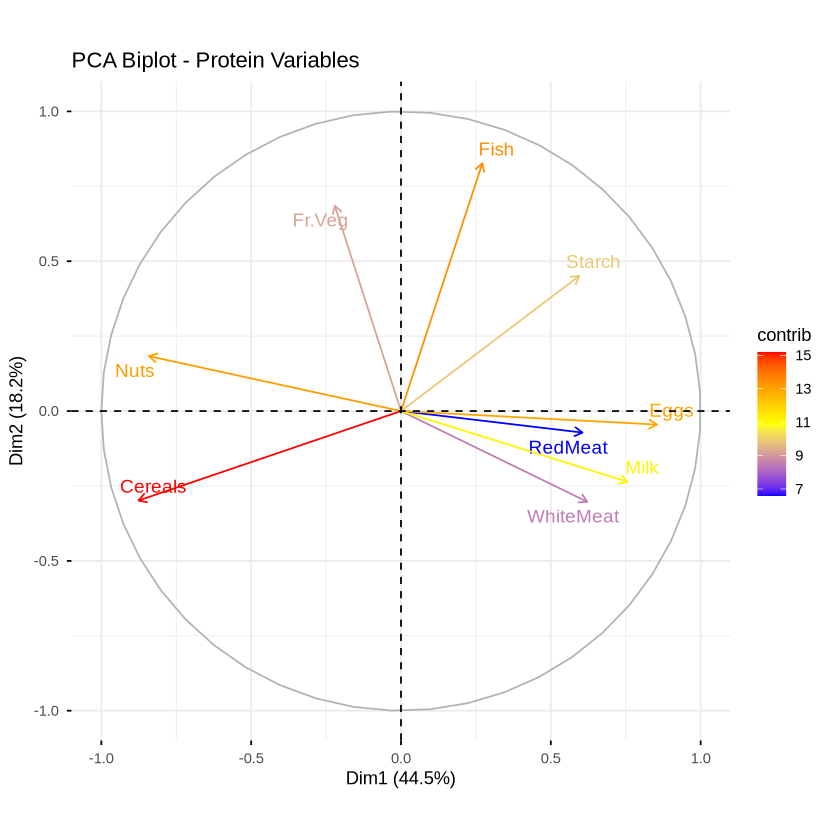

In [45]:
fviz_pca_var(protein_pca,
             col.var = "contrib",
             gradient.cols = c("blue", "yellow", "red"),
             repel = TRUE,
             title = "PCA Biplot - Protein Variables")


Which food categories point in the same direction (positively correlated)?
   - Eggs, RedMeat, Milk, WhiteMeat, and Starch all point to the
     RIGHT along Dim1 — they are positively correlated with each other
   - Fish and Fr.Veg both point UPWARD along Dim2 — positively
     correlated with each other

 Are any pointing in opposite directions (negatively correlated)?   
 - Cereals points LEFT while Eggs, RedMeat, Milk point RIGHT
     Cereals is negatively correlated with the animal protein group
   - Nuts points LEFT and slightly up, opposite to RedMeat/Eggs/Milk
     → Nuts is negatively correlated with the animal protein group
   - Fish/Fr.Veg point UP while WhiteMeat/Milk point DOWN-right
     → Fish is negatively correlated with WhiteMeat and Milk on Dim2

### Task 2.6: Cos² Chart (5 points)

Create a Cos² bar chart using `fviz_cos2()` for the first two components (`axes = 1:2`).

In a comment, answer: **Which food categories are well-represented by the first two components (high Cos²)? Are any poorly represented?**

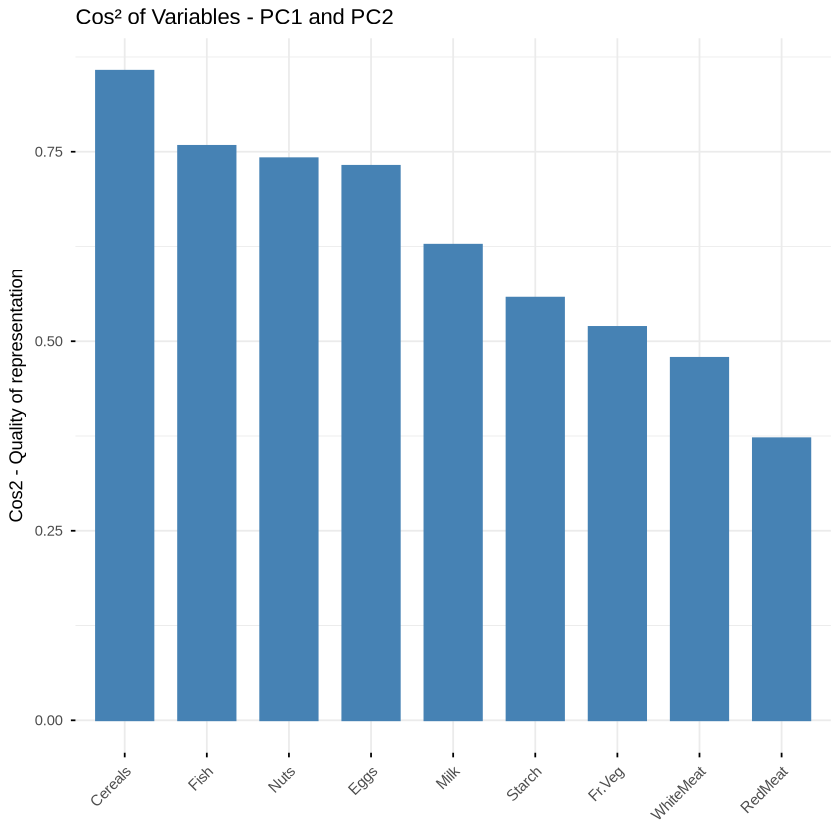

In [47]:
fviz_cos2(protein_pca,
          choice = "var",
          axes = 1:2,
          title = "Cos² of Variables - PC1 and PC2")

Cereals: highest cos² — best represented, strongly captured by PC1
Milk: second highest — well represented across PC1 and PC2
RedMeat: lower bar — only partially represented by PC1 + PC2, some variance exists in later components 
WhiteMeat: low cos, poorly represented by first two components, variance spreads into PC3 and beyond. 

### Task 2.7: Business Application Question (5 points)

Imagine you work for an international food company expanding into Europe. Based on your PCA results, answer the following in a comment:

1. If a country scores high on PC1, what does that tell you about its diet?
2. How could you use these principal components to **group countries** for a marketing strategy?
3. Why is PCA more useful here than just looking at all 9 food variables separately?

In [ ]:
#1 A country with a high PC1 score has a diet heavy in animal proteins, specifically high consumption of Eggs, Milk, RedMeat, WhiteMeat, and Starch. Typically these are wealtheir Western European countries. 
#2 It would help marketing strategy because you can mold the consumer adversiting different depending on the location. It avoids a one size fits all and targets each region based on actual dietary behavior 
#3 Looking at all 9 variables seperately requires unneccesary mental tracking of relationships between them. PCA condenses the variables into 2-3 principal components that capture the majoirty of variance 

---

## Part 3: Principal Component Regression (40 points)

PCR combines PCA with regression — useful when your predictors are correlated.

### Task 3.1: Load the PCR Data (5 points)

Load both `PCR_TRAIN DATA.csv` and `PCR_TEST DATA.csv` from the `data/module_3/` folder. Store them as `pcr_train` and `pcr_test`. Display the dimensions and first few rows of the training set.

In [8]:
pcr_train <- read.csv("../data/module_3/PCR_TRAIN DATA.csv")
pcr_test <- read.csv("../data/module_3/PCR_TEST DATA.csv")

head(pcr_train)
names(pcr_train)

,obsnam,tot,tyr,f1,f2,f3,f4,f5,f6,f7,⋯,f25,f26,f27,f28,f29,f30,try,tyr_log,try_log,tot_log
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,17mix35,3e-05,0.0e+00,-6.215,-5.809,-5.114,-3.963,-2.897,-2.269,-1.675,⋯,-1.520,-1.804,-2.044,-2.269,-2.496,-2.714,3.000e-05,-8.000000,-4.522879,-4.522879
2,19mix35,3e-05,3.0e-07,-5.516,-5.294,-4.823,-3.858,-2.827,-2.249,-1.683,⋯,-1.541,-1.814,-2.058,-2.289,-2.496,-2.712,2.970e-05,-6.522879,-4.527244,-4.522879
3,21mix35,3e-05,7.5e-07,-5.519,-5.294,-4.501,-3.863,-2.827,-2.280,-1.716,⋯,-1.565,-1.841,-2.084,-2.320,-2.521,-2.729,2.925e-05,-6.124939,-4.533874,-4.522879
4,23mix35,3e-05,1.5e-06,-5.294,-4.705,-4.262,-3.605,-2.726,-2.239,-1.681,⋯,-1.579,-1.852,-2.090,-2.316,-2.521,-2.743,2.850e-05,-5.823909,-4.545155,-4.522879
5,25mix35,3e-05,3.0e-06,-4.600,-4.069,-3.764,-3.262,-2.598,-2.191,-1.680,⋯,-1.619,-1.886,-2.141,-2.359,-2.585,-2.792,2.700e-05,-5.522879,-4.568636,-4.522879
6,27mix35,3e-05,7.5e-06,-3.812,-3.376,-3.026,-2.726,-2.249,-1.919,-1.541,⋯,-1.784,-2.058,-2.297,-2.507,-2.727,-2.970,2.250e-05,-5.124939,-4.647817,-4.522879


[1] "obsnam"  "tot"     "tyr"     "f1"      "f2"      "f3"      "f4"     
 [8] "f5"      "f6"      "f7"      "f8"      "f9"      "f10"     "f11"    
[15] "f12"     "f13"     "f14"     "f15"     "f16"     "f17"     "f18"    
[22] "f19"     "f20"     "f21"     "f22"     "f23"     "f24"     "f25"    
[29] "f26"     "f27"     "f28"     "f29"     "f30"     "try"     "tyr_log"
[36] "try_log" "tot_log"

### Task 3.2: Check Predictor Correlations (5 points)

Compute and display the correlation matrix for columns `f1` through `f10` in the training data.

In a comment, answer: **Are the predictors correlated? Why does this make standard regression a poor choice?**

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10
f1,1.00,1.00,0.99,0.97,0.91,0.67,0.12,-0.29,-0.47,-0.54
f2,1.00,1.00,1.00,0.97,0.91,0.68,0.15,-0.27,-0.44,-0.52
f3,0.99,1.00,1.00,0.99,0.94,0.73,0.21,-0.22,-0.40,-0.48
f4,0.97,0.97,0.99,1.00,0.98,0.81,0.31,-0.14,-0.33,-0.43
f5,0.91,0.91,0.94,0.98,1.00,0.91,0.48,0.04,-0.17,-0.27
f6,0.67,0.68,0.73,0.81,0.91,1.00,0.80,0.45,0.24,0.13
f7,0.12,0.15,0.21,0.31,0.48,0.80,1.00,0.89,0.77,0.69
f8,-0.29,-0.27,-0.22,-0.14,0.04,0.45,0.89,1.00,0.97,0.94
f9,-0.47,-0.44,-0.40,-0.33,-0.17,0.24,0.77,0.97,1.00,0.99
f10,-0.54,-0.52,-0.48,-0.43,-0.27,0.13,0.69,0.94,0.99,1.00


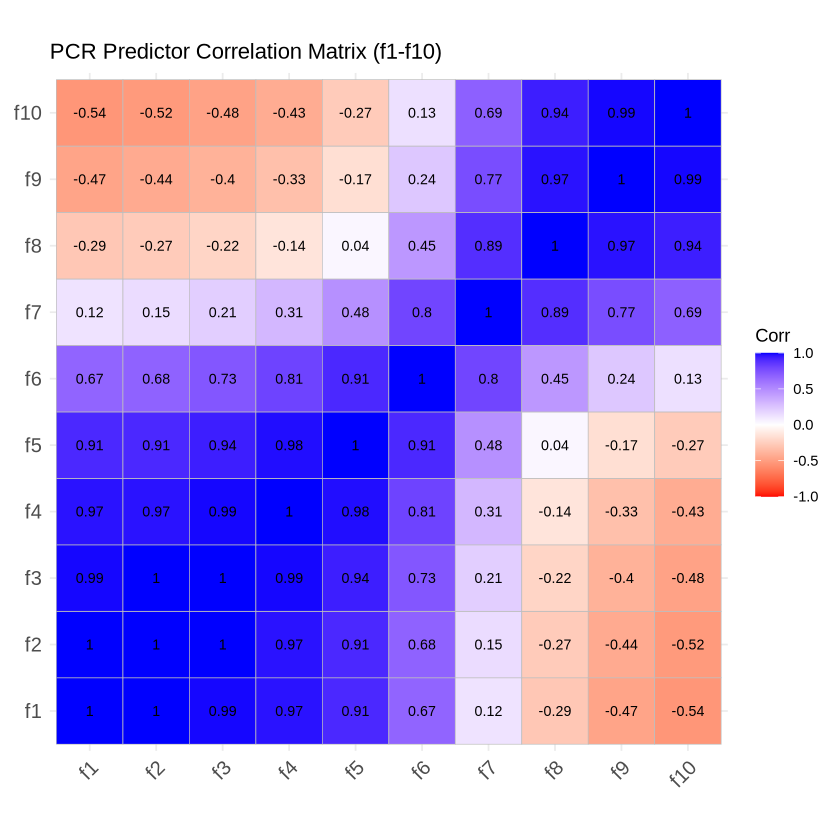

In [9]:
cor_matrix_pcr <- cor(pcr_train[, c("f1","f2","f3","f4","f5",
                                     "f6","f7","f8","f9","f10")])
round(cor_matrix_pcr, 2)

ggcorrplot(cor_matrix_pcr,
           lab = TRUE,
           lab_size = 3,
           colors = c("red", "white", "blue"),
           title = "PCR Predictor Correlation Matrix (f1-f10)")

the f1-f10 predictors are extremely highly correlated. This makes standard OLS regression a very poor choice because Standard errors become inflated, making all predictors appear statistically insignificant and you cant distingush the effect of each predictor 

### Task 3.3: Fit a PCR Model (5 points)

Fit a PCR model predicting `tot_log` from `f1` through `f10` using the training data. Use `scale = TRUE` and `validation = "CV"` for 10-fold cross-validation.

Display the model summary.

In [12]:
library(pls)
pcr_model <- pcr(tot_log ~ f1 + f2 + f3 + f4 + f5 + f6 + f7 + f8 + f9 + f10,
                 data = pcr_train,
                 scale = TRUE,
                 validation = "CV")
summary(pcr_model)


Attaching package: ‘pls’


The following object is masked from ‘package:stats’:

    loadings




Data: 	X dimension: 18 10 
	Y dimension: 18 1
Fit method: svdpc
Number of components considered: 10

VALIDATION: RMSEP
Cross-validated using 10 random segments.
       (Intercept)  1 comps  2 comps  3 comps  4 comps  5 comps  6 comps
CV           0.248   0.2737  0.06908  0.05601  0.06153  0.05642  0.06428
adjCV        0.248   0.2732  0.06846  0.05511  0.06041  0.05500  0.06291
       7 comps  8 comps  9 comps  10 comps
CV     0.06453  0.07836  0.08966   0.09980
adjCV  0.06277  0.07547  0.08605   0.09566

TRAINING: % variance explained
         1 comps  2 comps  3 comps  4 comps  5 comps  6 comps  7 comps  8 comps
X         59.399    98.39    99.88    99.95    99.98    99.99   100.00   100.00
tot_log    3.624    94.86    97.05    97.06    97.68    97.68    97.96    98.04
         9 comps  10 comps
X         100.00    100.00
tot_log    98.06     98.11


### Task 3.4: Validation Plot (5 points)

Create a validation plot using `validationplot()` with `val.type = "RMSEP"` to visualize cross-validation error by number of components.

In a comment, answer: **How many components would you select? Why?**

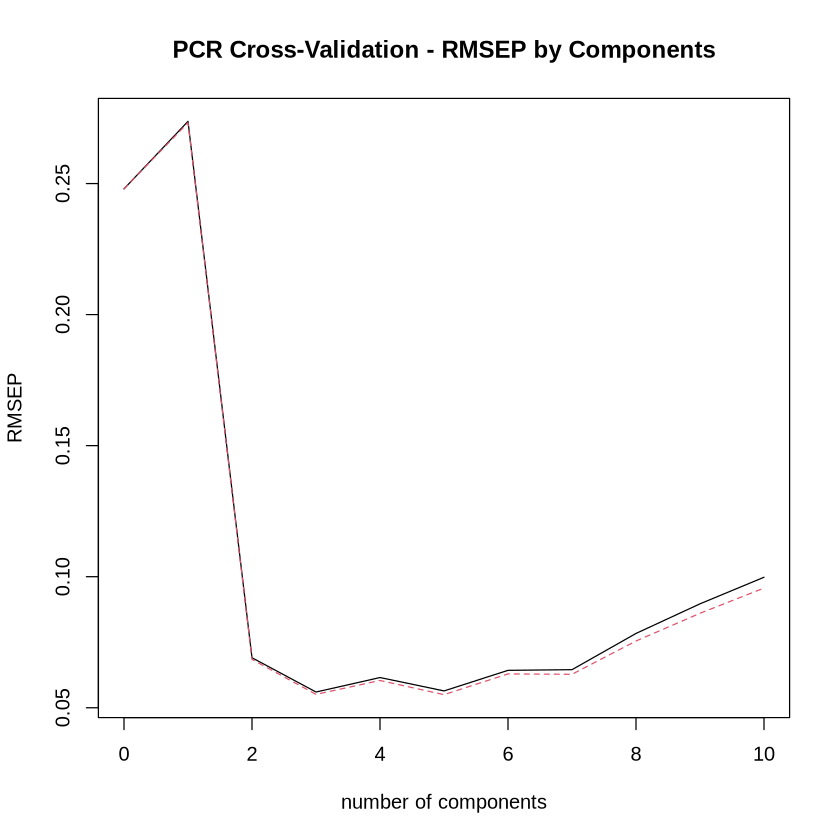

In [13]:
validationplot(pcr_model,
               val.type = "RMSEP",
               main = "PCR Cross-Validation - RMSEP by Components")

I would select  2 components because RMSEP drops sharply from 0 to 2, indicating the first two capture a majority of predictive information in f1-f10 

### Task 3.5: Make Predictions (5 points)

Using your chosen number of components (use `ncomp = 4`), predict `tot_log` on the **test** data. Store the predictions in a variable called `pcr_pred`.

In [14]:
pcr_pred <- predict(pcr_model,
                    newdata = pcr_test,
                    ncomp = 4)
pcr_pred                    

, , 4 comps

     tot_log
1  -5.968929
2  -6.051369
3  -5.999762
4  -5.967526
5  -5.944464
6  -5.950790
7  -5.951557
8  -4.951817
9  -4.969703
10 -4.967602
11 -4.939099
12 -4.948347
13 -4.942513
14 -4.951295
15 -3.943738

### Task 3.6: Calculate RMSE (5 points)

Calculate the Root Mean Square Error (RMSE) on the test set by comparing your predictions to the actual `tot_log` values.

**Formula:** `RMSE = sqrt(mean((actual - predicted)^2))`

Also calculate `RMSE / mean(actual)` to get a percentage — this tells you how large the error is relative to the average value.

In [15]:
actual <- pcr_test$tot_log
rmse <- sqrt(mean((actual - pcr_pred)^2))
rmse
rmse_pct <- rmse / mean(actual)
rmse_pct

[1] 0.0462024

[1] -0.008556

### Task 3.7: Interpret Your Results (5 points)

Answer the following in comments:

1. Is the RMSE acceptable? (Refer to the RMSE/Mean percentage — under 20% is good)
2. Why did we use PCR instead of regular regression for this dataset?
3. Give one real-world business example where you'd face the same problem (correlated predictors) and use PCR to solve it

In [ ]:
Yes the RMSE is acceptable, it is less than 1% which is much less than 20.
PCR was used instead of regular regressionb because the predictors were highly coreelated, making standard regression obselete. PCR transfroms the correlated predictors into uncorrelated principal componenets. 
A supplement store wants to predict monthly sales using 10 store metrics: customers per hour, average transcation $$, number of sales etc. These predictors are all highly correlated so regression would struggle. PCR breakdown these metrics until a few key aspects and use those to predict sales. 

### Task 3.8: When to Use What? (5 points)

In comments below, briefly explain the difference between PCA and PCR. When would you use each one? Fill in the blanks:

- "I would use **PCA** when my goal is to ____________________"
- "I would use **PCR** when my goal is to ____________________"
- "The key difference is that PCA is __________ while PCR is __________"

In [ ]:
I would use PCA when the goal is to explore and summarize my data by reducing many correlated variables into smaller sets 
I would use PCR when the goal is to predict a numeric outcome variable by first applying PCA to remove multicollinearity and then regressing on the resulting components to build an accurate model 
The key difference is PCA there is no outcome variable whereas PCR is used for prediction and uses an outcome variable. 

---

## Submission Checklist

Before submitting, verify:

- [ ] All cells run without errors
- [ ] All tasks have been attempted
- [ ] Code includes comments explaining your approach
- [ ] Interpretation questions are answered in comments
- [ ] Output is visible (not suppressed)

**Good luck!**